In [9]:
import numpy as np
import matplotlib.pyplot as plt
from solution import load_data
import warnings

warnings.filterwarnings(category=RuntimeWarning, action="error")

In [2]:
data = load_data()

Loading data...


In [33]:
class SVM:
    def __init__(self, eta, C, niter, batch_size, verbose):
        self.eta = eta
        self.C = C
        self.niter = niter
        self.batch_size = batch_size
        self.verbose = verbose

    def make_one_versus_all_labels(self, y, m, neg_label=-1.):
        """
        y : numpy array of shape (n,) -> Values in N
        m : int (num_classes)
        returns : numpy array of shape (n, m)
        """
        n = y.shape[0]
        I = neg_label * np.ones((n, m))
        I[range(n), y] = 1.
        return I

    def compute_loss(self, x, y, w=None):
        """
        x : numpy array of shape (minibatch size, num_features)
        y : numpy array of shape (minibatch size, num_classes)
            -> Values in {-1, +1}
        returns : float
        """
        scores = self.score(x, w=w)
        elementwise_loss = np.maximum(0, 2 - scores * y) ** 2
        return np.mean(elementwise_loss.sum(axis=1))

    def score(self, x, w=None):
        if w is None:
            w = self.w
        return x.dot(w)

    def compute_gradient(self, x, y, validate=False):
        """
        x : numpy array of shape (minibatch size, num_features)
        y : numpy array of shape (minibatch size, num_classes)
            -> Values in {-1, +1}
        returns : numpy array of shape (num_features, num_classes)
        """
        n, m = y.shape
        d = x.shape[1]
        xi = self.score(x) * y
        #if self.verbose: print(f"xi:\n{xi[:5]}")
        row_effects = -2. * (xi <= 2) * y * (2 - xi)
        #if self.verbose: print(f"row_effects:\n{row_effects[:5]}")
        assert (dims := row_effects.shape) == (n, m), f"Shape: {dims}"
        data_grad = 1. / n * x.T.dot(row_effects)
        assert (dims := data_grad.shape) == (d, m), f"Shape: {dims}"
        reg_term = self.C * self.w
        if validate:
            approx = self.approximate_gradient(x, y)
            if not np.allclose(data_grad, approx, atol=1e-3):
                max_error = np.absolute(data_grad - approx).max().max()
                print("\n\n".join([
                    "Error in gradient computation!",
                    f"Analytical:\n{data_grad}",
                    f"Approximated:\n{approx}",
                    f"Max error: {max_error}"
                ]))
                raise ValueError("Mistake with gradient!")
        return data_grad + reg_term
    
    def approximate_gradient(self, x, y, eps=1e-8):
        d, m = self.w.shape
        grad = np.zeros((d, m))
        def temp_w(k, j, direction):
            w = self.w.copy()
            w[k, j] += direction * eps
            return w
        for k in range(d):
            for j in range(m):
                l1 = self.compute_loss(x, y, w=temp_w(k, j,  1.))
                l0 = self.compute_loss(x, y, w=temp_w(k, j, -1.))
                grad[k, j] = (l1 - l0) / (2 * eps)
        return grad

    # Batcher function
    def minibatch(self, iterable1, iterable2, size=1):
        l = len(iterable1)
        n = size
        for ndx in range(0, l, n):
            index2 = min(ndx + n, l)
            yield iterable1[ndx: index2], iterable2[ndx: index2]

    def infer(self, x):
        """
        x : numpy array of shape (num_examples_to_infer, num_features)
        returns : numpy array of shape (num_examples_to_infer, num_classes)
        """
        scores = self.score(x)
        y_inferred = np.argmax(scores, axis=1)
        return self.make_one_versus_all_labels(y_inferred, self.m)

    def compute_accuracy(self, y_inferred, y):
        """
        y_inferred : numpy array of shape (num_examples, num_classes)
        y : numpy array of shape (num_examples, num_classes)
        returns : float
        """
        return np.mean(np.all(y_inferred == y, axis=1))

    def fit(self, x_train, y_train, x_test, y_test):
        """
        x_train : numpy array of shape (number of training examples, num_features)
        y_train : numpy array of shape (number of training examples, num_classes)
        x_test : numpy array of shape (number of testing examples, num_features)
        y_test : numpy array of shape (number of testing examples, num_classes)
        returns : float, float, float, float
        """
        self.num_features = x_train.shape[1]
        self.m = y_train.max() + 1
        y_train = self.make_one_versus_all_labels(y_train, self.m)
        y_test = self.make_one_versus_all_labels(y_test, self.m)
        self.w = np.zeros([self.num_features, self.m])

        train_losses = []
        train_accs = []
        test_losses = []
        test_accs = []

        for iteration in range(self.niter):
            # Train one pass through the training set
            for x, y in self.minibatch(x_train, y_train, size=self.batch_size):
                try:
                    grad = self.compute_gradient(x, y, validate=(iteration==0))
                except RuntimeWarning as e:
                    print("\n".join([
                        f"RuntimeWarning at iteration {iteration}",
                        f"Current weight matrix:\n{self.w}"
                    ]))
                    raise e
                self.w -= self.eta * grad

            # Measure loss and accuracy on training set
            train_loss = self.compute_loss(x_train, y_train)
            y_inferred = self.infer(x_train)
            train_accuracy = self.compute_accuracy(y_inferred, y_train)

            # Measure loss and accuracy on test set
            test_loss = self.compute_loss(x_test, y_test)
            y_inferred = self.infer(x_test)
            test_accuracy = self.compute_accuracy(y_inferred, y_test)

            if self.verbose:
                print(" | ".join([
                    f"Iteration {iteration}",
                    f"Train loss {train_loss:.04f}",
                    f"Train acc {train_accuracy:.04f}",
                    f"Test loss {test_loss:.04f}",
                    f"Test acc {test_accuracy:.04f}"
                ]))

            # Record losses, accs
            train_losses.append(train_loss)
            train_accs.append(train_accuracy)
            test_losses.append(test_loss)
            test_accs.append(test_accuracy)

        for value in ["train_losses", "train_accs", "test_losses", "test_accs"]:
            self.__dict__[value] = eval(value)

        return train_losses, train_accs, test_losses, test_accs

svm = SVM(eta=0.0001, C=2, niter=10, batch_size=100, verbose=True)
_ = svm.fit(*data)

Iteration 0 | Train loss 10.7706 | Train acc 0.6284 | Test loss 10.7619 | Test acc 0.6331
Iteration 1 | Train loss 10.0335 | Train acc 0.6398 | Test loss 10.0184 | Test acc 0.6446
Iteration 2 | Train loss 9.5395 | Train acc 0.6494 | Test loss 9.5199 | Test acc 0.6546
Iteration 3 | Train loss 9.1879 | Train acc 0.6584 | Test loss 9.1649 | Test acc 0.6637
Iteration 4 | Train loss 8.9291 | Train acc 0.6682 | Test loss 8.9037 | Test acc 0.6734
Iteration 5 | Train loss 8.7347 | Train acc 0.6779 | Test loss 8.7073 | Test acc 0.6838
Iteration 6 | Train loss 8.5864 | Train acc 0.6872 | Test loss 8.5576 | Test acc 0.6928
Iteration 7 | Train loss 8.4722 | Train acc 0.6939 | Test loss 8.4422 | Test acc 0.6999
Iteration 8 | Train loss 8.3833 | Train acc 0.6995 | Test loss 8.3525 | Test acc 0.7059
Iteration 9 | Train loss 8.3137 | Train acc 0.7038 | Test loss 8.2822 | Test acc 0.7102


### Test:  3a

In [8]:
def make_one_versus_all_labels(y, m):
    """
    y : numpy array of shape (n,)
    m : int (num_classes)
    returns : numpy array of shape (n, m)
    """
    n = y.shape[0]
    I = -1. * np.ones((n, m))
    I[range(n), y] = 1.
    return I

make_one_versus_all_labels(y=np.array([1, 0, 2]), m=4)

array([[-1.,  1., -1., -1.],
       [ 1., -1., -1., -1.],
       [-1., -1.,  1., -1.]])

### Learning plots

Training model with C=1.0
Training model with C=5.0
Training model with C=10.0


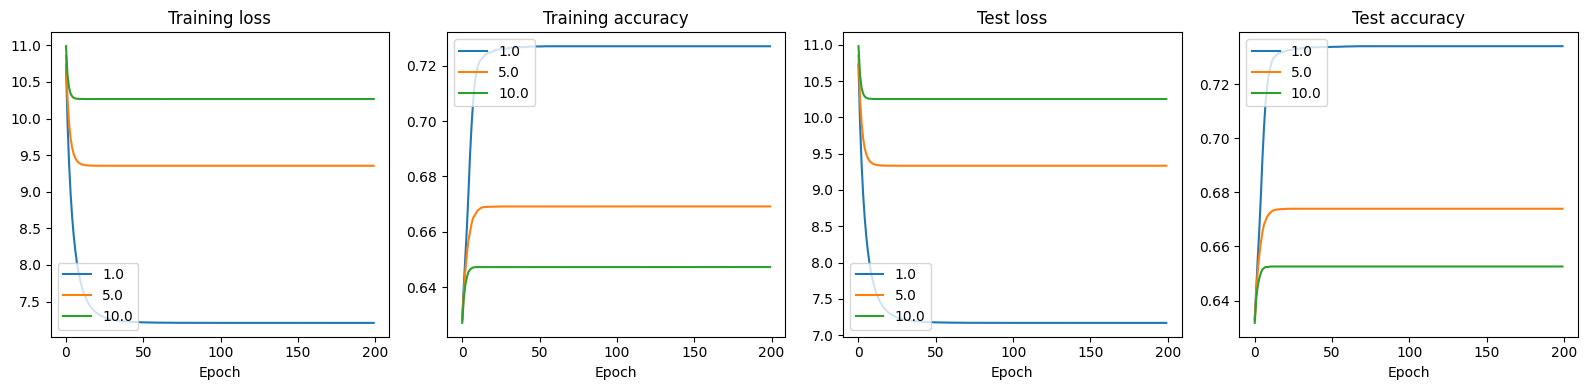

In [46]:
def plot_learning(C_vec: list,
                  data: tuple,
                  common_args: dict = {
                      "niter": 200,
                      "eta": 0.0001,
                      "batch_size": 100,
                      "verbose": False},
                  verbose: bool = True):
    models = {}
    for C in C_vec:
        if verbose:
            print(f"Training model with C={C}")
        model = SVM(**common_args, C=C)
        model.fit(*data)
        models[C] = model

    axes = plt.subplots(ncols=4, figsize=(16, 4))[1]
    for c, model in models.items():
        to_plot = {
            "Training loss": model.train_losses,
            "Training accuracy": model.train_accs,
            "Test loss": model.test_losses,
            "Test accuracy": model.test_accs
        }
        for ax, (title, value) in zip(axes, to_plot.items()):
            ax.plot(value, label=str(c))
            ax.set_xlabel("Epoch")
            ax.set_title(title)
            ax.legend()
    plt.tight_layout()
    plt.show()

plot_learning([1., 5., 10.], data=data)

Training model with C=0.0
Training model with C=0.01
Training model with C=0.1


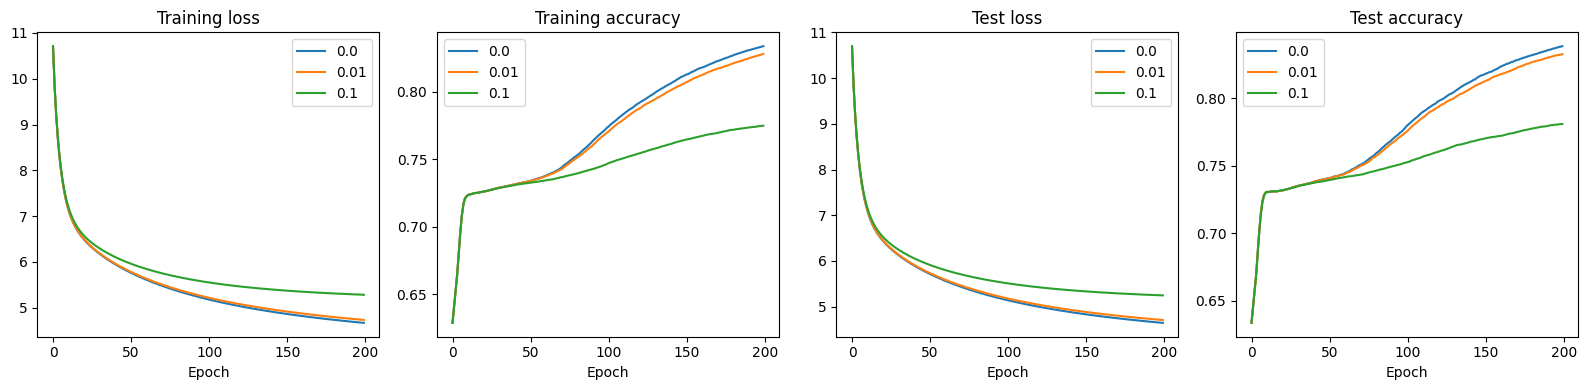

In [47]:
plot_learning([0., .01, .1], data=data)